# Imports

In [1]:
import os
import json
import time
import pandas as pd
import numpy as np
import opensim as osim
import matplotlib.pyplot as plt
import msk_modelling_python as msk
import matplotlib.pyplot as plt
parent_dir = os.path.dirname(os.getcwd())
start_time = time.time()
################

import vtk


In [2]:
print("VTK version: ", vtk.vtkVersion.GetVTKVersion())

VTK version:  9.4.1


# Test functions

In [ ]:

def read_vtp_file(filename):
    """
    Reads a VTK PolyData file (.vtp) and returns a vtkPolyData object.
    """
    reader = vtk.vtkXMLPolyDataReader()
    reader.SetFileName(filename)
    reader.Update()
    return reader.GetOutput()

def visualise_vtp(vtp_file):
    """
    Visualises a vtkPolyData object.
    """
    mapper = vtk.vtkPolyDataMapper()
    mapper.SetInputData(vtp_file)
    actor = vtk.vtkActor()
    actor.SetMapper(mapper)
    renderer = vtk.vtkRenderer()
    renderer.AddActor(actor)
    renderer.SetBackground(0.1, 0.2, 0.4)
    render_window = vtk.vtkRenderWindow()
    render_window.AddRenderer(renderer)
    render_window_interactor = vtk.vtkRenderWindowInteractor()
    render_window_interactor.SetRenderWindow(render_window)
    render_window.Render()
    render_window_interactor.Start()
    
# file_path = r'C:\Git\research_data\models\Gerometry_bones\femur\femur.vtp'
# vtp_file = read_vtp_file(file_path)
# visualise_vtp(vtp_file)


# Build knee model

## Create functions

## Create bodies and joints

In [32]:

# Define global model where the leg lives.
leg = osim.Model()
leg.setUseVisualizer(True)

# ---------------------------------------------------------------------------
# Create two links, each with a mass of 1 kg, centre of mass at the body's
# origin, and moments and products of inertia of zero.
# ---------------------------------------------------------------------------

length_femur = 0.5
length_tibia = 1
length_foot = 0.5

femur = osim.Body("femur",
                    length_femur,
                    osim.Vec3(0, 0, 0),
                    osim.Inertia(0, 0, 0))
tibia = osim.Body("tibia",
                   length_tibia,
                   osim.Vec3(0, 0, 0),
                   osim.Inertia(0, 0, 0))

foot = osim.Body("foot",
                    length_foot,
                    osim.Vec3(0, 0, 0),
                    osim.Inertia(0, 0, 0))


# ---------------------------------------------------------------------------
# Connect the bodies with pin joints. Assume each body is 1m long.
# ---------------------------------------------------------------------------

hip = osim.PinJoint("hip",
                    leg.getGround(),  # PhysicalFrame
                    osim.Vec3(0, 0, 0),
                    osim.Vec3(0, 0, 0),
                    femur,  # PhysicalFrame
                    osim.Vec3(0, length_femur, 0),
                    osim.Vec3(0, 0, 0))

knee = osim.PinJoint("knee",
                     femur,  # PhysicalFrame
                     osim.Vec3(0, 0, 0),
                     osim.Vec3(0, 0, 0),
                     tibia,  # PhysicalFrame
                     osim.Vec3(0, length_tibia, 0),
                     osim.Vec3(0, 0, 0))

ankle = osim.PinJoint("ankle",
                        tibia,  # PhysicalFrame
                        osim.Vec3(0, 0, 0),
                        osim.Vec3(0, 0, 0),
                        foot,  # PhysicalFrame
                        osim.Vec3(0, 0.5, 0),
                        osim.Vec3(0, 0, 0))


## Create muscles and controller (brain)

In [33]:

# ---------------------------------------------------------------------------
# Add a muscle that flexes the elbow (actuator for robotics people).
# ---------------------------------------------------------------------------
quadriceps = osim.Millard2012EquilibriumMuscle("quadriceps",  # Muscle name
                                               300.0,  # Max isometric force
                                               0.6,  # Optimal fibre length
                                               0.55,  # Tendon slack length
                                               0.0)  # Pennation angle
quadriceps.addNewPathPoint("origin",
                           femur,
                           osim.Vec3(0, 0.8, 0))

quadriceps.addNewPathPoint("insertion",
                           tibia,
                           osim.Vec3(0, 0.7, 0))

hamstrings = osim.Millard2012EquilibriumMuscle("hamstrings",  # Muscle name
                                               200.0,  # Max isometric force
                                               0.6,  # Optimal fibre length
                                               0.55,  # Tendon slack length
                                               0.0)  # Pennation angle
hamstrings.addNewPathPoint("origin",
                           femur,
                           osim.Vec3(0, 0.2, 0))

hamstrings.addNewPathPoint("insertion",
                           tibia,
                           osim.Vec3(0, 1, 0))

# ---------------------------------------------------------------------------
# Add a controller that specifies the excitation of the muscles.
# ---------------------------------------------------------------------------

brain = osim.PrescribedController()
brain.addActuator(quadriceps)
brain.addActuator(hamstrings)
brain.prescribeControlForActuator("quadriceps",
                                  osim.StepFunction(0.1, 0.2, 0.3, 0.3))
brain.prescribeControlForActuator("hamstrings",
                                  osim.StepFunction(0.5, 1.0, 2.3, 3.0))



## Add components to the model

In [34]:
# ---------------------------------------------------------------------------
# Build model with components created above.
# ---------------------------------------------------------------------------

leg.addBody(femur)
leg.addBody(tibia)
leg.addBody(foot)
leg.addJoint(hip)
leg.addJoint(knee)
leg.addJoint(ankle)
leg.addForce(quadriceps)
leg.addForce(hamstrings)
leg.addController(brain)

# ---------------------------------------------------------------------------
# Add a console reporter to print the muscle fibre force and knee angle.
# ---------------------------------------------------------------------------

# We want to write our simulation results to the console.
reporter = osim.ConsoleReporter()
reporter.set_report_time_interval(1.0)
reporter.addToReport(quadriceps.getOutput("fiber_force"))
reporter.addToReport(hamstrings.getOutput("fiber_force"))
knee_coord = knee.getCoordinate().getOutput("value")
reporter.addToReport(knee_coord, "knee_angle")
leg.addComponent(reporter)

# ---------------------------------------------------------------------------
# Add display geometry. 
# ---------------------------------------------------------------------------

bodyGeometry = osim.Ellipsoid(0.1, 0.5, 0.1)
bodyGeometry.setColor(osim.Gray)
femurCenter = osim.PhysicalOffsetFrame()
femurCenter.setName("femurCenter")
femurCenter.setParentFrame(femur)
femurCenter.setOffsetTransform(osim.Transform(osim.Vec3(0, 0.5, 0)))
femur.addComponent(femurCenter)
femurCenter.attachGeometry(bodyGeometry.clone())

tibiaCenter = osim.PhysicalOffsetFrame()
tibiaCenter.setName("tibiaCenter")
tibiaCenter.setParentFrame(tibia)
tibiaCenter.setOffsetTransform(osim.Transform(osim.Vec3(0, 0.5, 0)))
tibia.addComponent(tibiaCenter)
tibiaCenter.attachGeometry(bodyGeometry.clone())

foot_vtp = r"C:\Users\Bas\Downloads\Final 3D STL Models-stl\Left\VHM_Left_Bone_Phalanges_smooth.stl"
ankleBodyGeometry = osim.Mesh(foot_vtp)
ankleCenter = osim.PhysicalOffsetFrame()
ankleCenter.setName("ankleCenter")
ankleCenter.setParentFrame(foot)
ankleCenter.setOffsetTransform(osim.Transform(osim.Vec3(0, 0.25, 0)))
foot.addComponent(ankleCenter)
ankleCenter.attachGeometry(bodyGeometry.clone())




# Build knee model

## Create bodies and joints

In [2]:

# Define global model where the leg lives.
leg = osim.Model()
leg.setUseVisualizer(True)

# ---------------------------------------------------------------------------
# Create two links, each with a mass of 1 kg, centre of mass at the body's
# origin, and moments and products of inertia of zero.
# ---------------------------------------------------------------------------

length_femur = 0.5
length_tibia = 1
length_foot = 0.5

femur = osim.Body("femur",
                    length_femur,
                    osim.Vec3(0, 0, 0),
                    osim.Inertia(0, 0, 0))
tibia = osim.Body("tibia",
                   length_tibia,
                   osim.Vec3(0, 0, 0),
                   osim.Inertia(0, 0, 0))

foot = osim.Body("foot",
                    length_foot,
                    osim.Vec3(0, 0, 0),
                    osim.Inertia(0, 0, 0))


# ---------------------------------------------------------------------------
# Connect the bodies with pin joints. Assume each body is 1m long.
# ---------------------------------------------------------------------------

hip = osim.PinJoint("hip",
                    leg.getGround(),  # PhysicalFrame
                    osim.Vec3(0, 0, 0),
                    osim.Vec3(0, 0, 0),
                    femur,  # PhysicalFrame
                    osim.Vec3(0, length_femur, 0),
                    osim.Vec3(0, 0, 0))

knee = osim.PinJoint("knee",
                     femur,  # PhysicalFrame
                     osim.Vec3(0, 0, 0),
                     osim.Vec3(0, 0, 0),
                     tibia,  # PhysicalFrame
                     osim.Vec3(0, length_tibia, 0),
                     osim.Vec3(0, 0, 0))

ankle = osim.PinJoint("ankle",
                        tibia,  # PhysicalFrame
                        osim.Vec3(0, 0, 0),
                        osim.Vec3(0, 0, 0),
                        foot,  # PhysicalFrame
                        osim.Vec3(0, 0.5, 0),
                        osim.Vec3(0, 0, 0))


## Create muscles and controller (brain)

In [3]:

# ---------------------------------------------------------------------------
# Add a muscle that flexes the elbow (actuator for robotics people).
# ---------------------------------------------------------------------------
quadriceps = osim.Millard2012EquilibriumMuscle("quadriceps",  # Muscle name
                                               300.0,  # Max isometric force
                                               0.6,  # Optimal fibre length
                                               0.55,  # Tendon slack length
                                               0.0)  # Pennation angle
quadriceps.addNewPathPoint("origin",
                           femur,
                           osim.Vec3(0, 0.8, 0))

quadriceps.addNewPathPoint("insertion",
                           tibia,
                           osim.Vec3(0, 0.7, 0))

hamstrings = osim.Millard2012EquilibriumMuscle("hamstrings",  # Muscle name
                                               200.0,  # Max isometric force
                                               0.6,  # Optimal fibre length
                                               0.55,  # Tendon slack length
                                               0.0)  # Pennation angle
hamstrings.addNewPathPoint("origin",
                           femur,
                           osim.Vec3(0, 0.2, 0))

hamstrings.addNewPathPoint("insertion",
                           tibia,
                           osim.Vec3(0, 1, 0))

# ---------------------------------------------------------------------------
# Add a controller that specifies the excitation of the muscles.
# ---------------------------------------------------------------------------

brain = osim.PrescribedController()
brain.addActuator(quadriceps)
brain.addActuator(hamstrings)
brain.prescribeControlForActuator("quadriceps",
                                  osim.StepFunction(0.1, 0.2, 0.3, 0.3))
brain.prescribeControlForActuator("hamstrings",
                                  osim.StepFunction(0.5, 1.0, 2.3, 3.0))



## Add components to the model

In [4]:
# ---------------------------------------------------------------------------
# Build model with components created above.
# ---------------------------------------------------------------------------

leg.addBody(femur)
leg.addBody(tibia)
leg.addBody(foot)
leg.addJoint(hip)
leg.addJoint(knee)
leg.addJoint(ankle)
leg.addForce(quadriceps)
leg.addForce(hamstrings)
leg.addController(brain)

# ---------------------------------------------------------------------------
# Add a console reporter to print the muscle fibre force and knee angle.
# ---------------------------------------------------------------------------

# We want to write our simulation results to the console.
reporter = osim.ConsoleReporter()
reporter.set_report_time_interval(1.0)
reporter.addToReport(quadriceps.getOutput("fiber_force"))
reporter.addToReport(hamstrings.getOutput("fiber_force"))
knee_coord = knee.getCoordinate().getOutput("value")
reporter.addToReport(knee_coord, "knee_angle")
leg.addComponent(reporter)

# ---------------------------------------------------------------------------
# Add display geometry. 
# ---------------------------------------------------------------------------

bodyGeometry = osim.Ellipsoid(0.1, 0.5, 0.1)
bodyGeometry.setColor(osim.Gray)
femurCenter = osim.PhysicalOffsetFrame()
femurCenter.setName("femurCenter")
femurCenter.setParentFrame(femur)
femurCenter.setOffsetTransform(osim.Transform(osim.Vec3(0, 0.5, 0)))
femur.addComponent(femurCenter)
femurCenter.attachGeometry(bodyGeometry.clone())

tibiaCenter = osim.PhysicalOffsetFrame()
tibiaCenter.setName("tibiaCenter")
tibiaCenter.setParentFrame(tibia)
tibiaCenter.setOffsetTransform(osim.Transform(osim.Vec3(0, 0.5, 0)))
tibia.addComponent(tibiaCenter)
tibiaCenter.attachGeometry(bodyGeometry.clone())

foot_vtp = r"C:\Users\Bas\Downloads\Final 3D STL Models-stl\Left\VHM_Left_Bone_Phalanges_smooth.stl"
ankleBodyGeometry = osim.Mesh(foot_vtp)
ankleCenter = osim.PhysicalOffsetFrame()
ankleCenter.setName("ankleCenter")
ankleCenter.setParentFrame(foot)
ankleCenter.setOffsetTransform(osim.Transform(osim.Vec3(0, 0.25, 0)))
foot.addComponent(ankleCenter)
ankleCenter.attachGeometry(bodyGeometry.clone())




# Initiate the system and run the model simulation

In [ ]:
# ---------------------------------------------------------------------------
# Configure the model.
# ---------------------------------------------------------------------------

state = leg.initSystem()
# Fix the hip at its default angle and begin with the knee flexed.
hip.getCoordinate().setLocked(state, True)
knee.getCoordinate().setValue(state, osim.SimTK_PI) # 180 degrees
ankle.getCoordinate().setValue(state, 0.5) # 90 degrees
leg.equilibrateMuscles(state)

# ---------------------------------------------------------------------------
# Simulate.
# ---------------------------------------------------------------------------

manager = osim.Manager(leg)
state.setTime(0)
manager.initialize(state)
state = manager.integrate(10.0)

# ---------------------------------------------------------------------------
# Print/save model file
# ---------------------------------------------------------------------------

leg.printToXML(os.path.join(parent_dir, "leg.osim"))



True

# End test

In [16]:
################
print(f"--- {time.time() - start_time} seconds ---")

--- 3.2267627716064453 seconds ---


# Muscle model

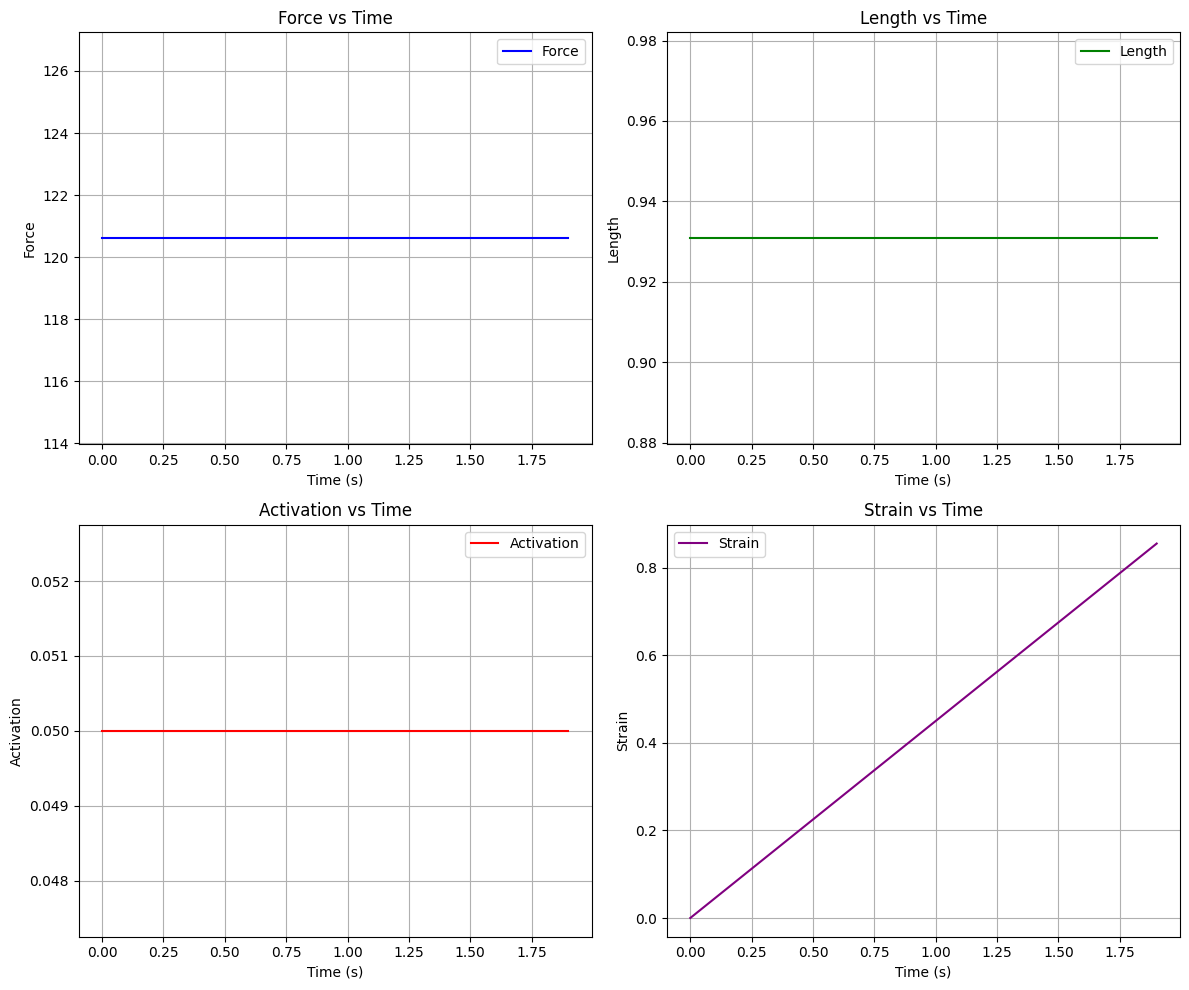

In [59]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Create a muscle model and configure it.
# ---------------------------------------------------------------------------

# Define a new muscle model
muscle_model = osim.Model()
muscle_model.setUseVisualizer(False)  # Disable visualization

# Create a body to attach the muscle
body = osim.Body("body", 1.0, osim.Vec3(0), osim.Inertia(0))
muscle_model.addBody(body)

# Create a ground-to-body joint
joint = osim.PinJoint("joint",
                      muscle_model.getGround(),
                      osim.Vec3(0),
                      osim.Vec3(0),
                      body,
                      osim.Vec3(0),
                      osim.Vec3(0))
muscle_model.addJoint(joint)

# Define the muscle
muscle = osim.Millard2012EquilibriumMuscle("muscle",
                                           200.0,  # Max isometric force
                                           0.6,    # Optimal fiber length
                                           0.55,   # Tendon slack length
                                           0.0)    # Pennation angle
muscle.addNewPathPoint("origin", muscle_model.getGround(), osim.Vec3(0, 1, 0))
muscle.addNewPathPoint("insertion", body, osim.Vec3(0, -0.5, 0))
muscle_model.addForce(muscle)

# Add a controller to activate the muscle
controller = osim.PrescribedController()
controller.addActuator(muscle)
step_function = osim.StepFunction(0.1, 0.2, 0.3, 0.5)  # Adjust timing and values as needed
controller.prescribeControlForActuator("muscle", step_function)
muscle_model.addController(controller)

# ---------------------------------------------------------------------------
# Configure the simulation.
# ---------------------------------------------------------------------------

state = muscle_model.initSystem()

# Simulate with incremental strain increase
strain = 0.9
time_step = 0.1
total_time = 2.0
current_time = 0.0
initial_length = muscle.getFiberLength(state)
strain_increment = strain / (total_time / time_step)

# Dataframe to store simulation results
results = pd.DataFrame(columns=["Time", "Force", "Length", "Activation", "Strain"])

while current_time <= total_time:
    # Incrementally increase strain
    current_strain = (current_time / total_time) * strain
    perturbed_length = initial_length * (1 + current_strain)
    muscle.setFiberLength(state, perturbed_length)
    muscle_model.equilibrateMuscles(state)

    # Record data
    fiber_force = muscle.getFiberForce(state)
    fiber_length = muscle.getFiberLength(state)
    activation = muscle.getActivation(state)
    results.loc[len(results)] = {
        "Time": current_time,
        "Force": fiber_force,
        "Length": fiber_length,
        "Activation": activation,
        "Strain": current_strain
    }

    # Update time
    current_time += time_step

# ---------------------------------------------------------------------------
# Plot and save the results.
# ---------------------------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot Force
axs[0, 0].plot(results["Time"], results["Force"], label="Force", color="blue")
axs[0, 0].set_title("Force vs Time")
axs[0, 0].set_xlabel("Time (s)")
axs[0, 0].set_ylabel("Force")
axs[0, 0].grid()
axs[0, 0].legend()

# Plot Length
axs[0, 1].plot(results["Time"], results["Length"], label="Length", color="green")
axs[0, 1].set_title("Length vs Time")
axs[0, 1].set_xlabel("Time (s)")
axs[0, 1].set_ylabel("Length")
axs[0, 1].grid()
axs[0, 1].legend()

# Plot Activation
axs[1, 0].plot(results["Time"], results["Activation"], label="Activation", color="red")
axs[1, 0].set_title("Activation vs Time")
axs[1, 0].set_xlabel("Time (s)")
axs[1, 0].set_ylabel("Activation")
axs[1, 0].grid()
axs[1, 0].legend()

# Plot Strain
axs[1, 1].plot(results["Time"], results["Strain"], label="Strain", color="purple")
axs[1, 1].set_title("Strain vs Time")
axs[1, 1].set_xlabel("Time (s)")
axs[1, 1].set_ylabel("Strain")
axs[1, 1].grid()
axs[1, 1].legend()

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig("muscle_simulation_subplots.png")
plt.show()


In [ ]:
# manager.integrate(current_time + time_step)


<Swig Object of type 'double *' at 0x0000026AEA06D7B0>

In [36]:
state.setTime(osim.Vec2(0, 1))

TypeError: in method 'State_setTime', argument 2 of type 'double'